In [107]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [108]:
X,y=make_regression(n_samples=100,n_features=1,noise=10,random_state=42)

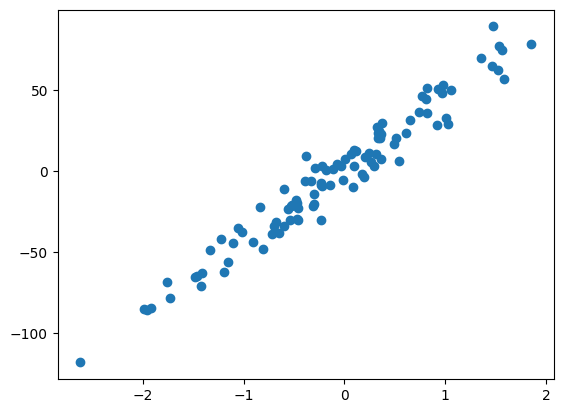

In [109]:
plt.scatter(X,y)

In [110]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [111]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[44.24418216]
0.09922221422587718


In [112]:
m=44.43


In [113]:
class GDRegressor:
    def __init__(self,learning_rate,n_iters):
        self.m=44.43
        self.b=-120
        self.lr=learning_rate
        self.n_iters=n_iters
        
    def fit(self,X,y):
        for i in range(self.n_iters):
            loss_slope=-2*np.sum(y-self.m*X.ravel()-self.b)
            self.b=self.b-self.lr*loss_slope
        print(self.b)     

In [114]:
gd=GDRegressor(0.001,100)
gd.fit(X_train,y_train)

0.1231252876223028


In [115]:
np.mean(cross_val_score(lr,X_train,y_train,cv=10 ,scoring='r2'))

np.float64(0.933669600346813)

In [116]:
class GDRegressor1:
    def __init__(self,learning_rate,n_iters):
        self.m=400
        self.b=1200
        self.lr=learning_rate
        self.n_iters=n_iters
        
    def fit(self,X,y):
        for i in range(self.n_iters):
            loss_slope_b=-2*np.sum(y-self.m*X.ravel()-self.b)
            loss_slope_m=-2*np.sum((y-self.m*X.ravel()-self.b)*X.ravel())
            self.m=self.m-self.lr*loss_slope_m
            self.b=self.b-self.lr*loss_slope_b
        print(self.b)     
        print(self.m)
    def predict(self,X):
        return self.m*X.ravel()+self.b

In [117]:
gd1=GDRegressor1(0.001,100)
gd1.fit(X_train,y_train)

0.10014896475173152
44.24586812638365


In [118]:
from sklearn.metrics import r2_score
y_pred=gd1.predict(X_test)
print(r2_score(y_test,y_pred))

0.9374214761436503
